# AI-Driven Driver Redistribution for Ride-Hailing Platforms
Eduardo Alan Hernandez Villasana - Jan 2026

Data Source: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

## Summary

This notebook focuses on analyzing ride demand patterns and estimating the potential impact of improving driver distribution across time and space.

Raw trip-level data was cleaned and preprocessed to ensure temporal consistency and data quality. Trips were aggregated into fixed 30-minute intervals and grouped by geographic zones, enabling the analysis of short-term demand variability while maintaining computational efficiency.

To approximate the effect of improved driver allocation, the analysis models passenger waiting time as a function of local demand intensity within each zone–time window. A more balanced supply–demand scenario was then assumed to estimate potential reductions in passenger waiting time

The primary evaluation metrics derived from this approach include passenger-minutes and passenger-hours saved per time window, per day, and per year. These metrics were chosen to translate operational improvements into interpretable, business-relevant quantities.

Due to time limitations, some intended parts were excluded from the current scope. Specifically, no geospatial visualizations (e.g., demand heatmaps), animated outputs (GIFs), or explicit optimization techniques (such as linear programming) were implemented. 


## Libraries, Constants and Initial Parameters

In [ ]:
import pandas as pd
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import duckdb
import os
from datetime import timedelta

from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

import geopandas as gpd
import networkx as nx
from scipy.spatial import cKDTree
from sklearn.linear_model import LinearRegression

In [2]:
data_path = "fhvhv"
time_window = 30

In [3]:
#df_fhv = pd.read_parquet("fhv_tripdata_2025-01.parquet")
df_fhvhv = pd.read_parquet("fhvhv/2025/fhvhv_tripdata_2025-01.parquet")
#dg_green = pd.read_parquet("green_tripdata_2025-01.parquet")
#df_yellos = pd.read_parquet("yellow_tripdata_2025-01.parquet")

In [3]:
zone_table = pd.read_csv("taxi_zone_lookup.csv")

## Functions

In [73]:
def build_knn_zone_graph(gdf_nodes: gpd.GeoDataFrame, k: int = 6) -> nx.Graph:
    """
    Build a weighted undirected kNN graph:
      - nodes: LocationID
      - edges: connect each zone to its k nearest neighbors
      - weight: distance_km
    """
    coords = gdf_nodes[["cx", "cy"]].to_numpy()
    loc_ids = gdf_nodes["LocationID"].to_numpy()

    tree = cKDTree(coords)
    # k+1 porque el vecino más cercano de un punto es él mismo (dist=0)
    dists, idxs = tree.query(coords, k=k + 1)

    G = nx.Graph()

    # Add nodes with attributes (name/borough)
    for _, row in gdf_nodes.iterrows():
        G.add_node(
            int(row["LocationID"]),
            ZoneName=row.get("ZoneName", None),
            Borough=row.get("Borough", None),
            cx=float(row["cx"]),
            cy=float(row["cy"]),
        )

    # Add edges
    for i, src_id in enumerate(loc_ids):
        for j in range(1, k + 1):  # saltamos j=0 (self)
            nbr_index = idxs[i, j]
            dst_id = loc_ids[nbr_index]
            dist_m = dists[i, j]
            dist_km = float(dist_m / 1000.0)

            # edge weight = distance
            G.add_edge(int(src_id), int(dst_id), weight=dist_km, distance_km=dist_km)

    return G

In [75]:
def show_neighbors(G: nx.Graph, zone_id: int, top_n: int = 10):
    nbrs = []
    for n in G.neighbors(zone_id):
        nbrs.append((n, G[zone_id][n]["distance_km"]))
    nbrs = sorted(nbrs, key=lambda x: x[1])[:top_n]
    return nbrs

In [77]:
def supply_and_shortage_for_time(df_agg_pd: pd.DataFrame, pred_df: pd.DataFrame, t_supply):
    """
    df_agg_pd: pandas con df_agg (o subset) con columns: zone,time,drop_offs,pick_ups...
    pred_df: output de predict_next_pickups_for_time
    t_supply: timestamp t (mismo bucket)
    """
    supply = (
        df_agg_pd[df_agg_pd["time"] == t_supply][["zone", "drop_offs"]]
        .groupby("zone", as_index=False)["drop_offs"].sum()
        .rename(columns={"drop_offs": "supply_dropoffs_t"})
    )

    merged = pred_df.merge(supply, on="zone", how="left")
    merged["supply_dropoffs_t"] = merged["supply_dropoffs_t"].fillna(0.0)

    merged["shortage_score"] = merged["pred_pickups_t_plus_1"] - merged["supply_dropoffs_t"]
    return merged

In [78]:
def attach_zone_scores_to_graph(G: nx.Graph, zone_scores: pd.DataFrame):
    """
    zone_scores columns expected: zone, pred_pickups_t_plus_1, supply_dropoffs_t, shortage_score
    """
    zmap = zone_scores.set_index("zone").to_dict(orient="index")
    for node in G.nodes():
        if node in zmap:
            G.nodes[node]["pred_pickups_t_plus_1"] = float(zmap[node]["pred_pickups_t_plus_1"])
            G.nodes[node]["supply_dropoffs_t"] = float(zmap[node]["supply_dropoffs_t"])
            G.nodes[node]["shortage_score"] = float(zmap[node]["shortage_score"])
        else:
            G.nodes[node]["pred_pickups_t_plus_1"] = 0.0
            G.nodes[node]["supply_dropoffs_t"] = 0.0
            G.nodes[node]["shortage_score"] = 0.0

In [96]:
# preduct pickups t+1
def predict_pickups_t_plus_1(df_feat: pl.DataFrame, feature_cols, model, t_bucket) -> pd.DataFrame:
    cols = ["zone", "time"] + [c for c in feature_cols if c not in ("zone", "time")]

    batch = (
        df_feat
        .filter(pl.col("time") == t_bucket)
        .select(cols)
    )

    pdf = batch.to_pandas()
    pdf["zone"] = pdf["zone"].astype("category")

    X = pdf[feature_cols].copy()
    X["zone"] = X["zone"].astype("category")

    yhat = model.predict(X)

    return pd.DataFrame({
        "zone": pdf["zone"].astype(int),
        "time": pdf["time"],
        "pred_pickups": yhat
    })

In [82]:
def get_supply_dropoffs_at_t(df_source: pl.DataFrame, t_bucket) -> pd.DataFrame:
    out = (
        df_source
        .filter(pl.col("time") == t_bucket)
        .select(["zone", "drop_offs"])
        .group_by("zone")
        .agg(pl.sum("drop_offs").alias("supply_dropoffs"))
        .to_pandas()
    )
    out["zone"] = out["zone"].astype(int)
    return out

In [83]:
def greedy_reposition(
    G: nx.Graph,
    demand_supply_df: pd.DataFrame,
    max_distance_km: float = 8.0
):
    """
    demand_supply_df columns: zone, pred_pickups, supply_dropoffs
    Returns:
      moves_df: from_zone, to_zone, drivers_moved, distance_km
      final_df: zone, pred_pickups, supply_before, supply_after, shortage_before, shortage_after
    """
    df = demand_supply_df.copy()

    df["supply_before"] = df["supply_dropoffs"].astype(float)
    df["shortage_before"] = df["pred_pickups"].astype(float) - df["supply_before"]


    df["need"] = df["shortage_before"].clip(lower=0.0)
    df["surplus"] = (-df["shortage_before"]).clip(lower=0.0)

    need = dict(zip(df["zone"], df["need"]))
    surplus = dict(zip(df["zone"], df["surplus"]))

    deficit_zones = [z for z in need if need[z] > 0]
    surplus_zones = [z for z in surplus if surplus[z] > 0]

    deficit_zones.sort(key=lambda z: need[z], reverse=True)

    moves = []

    for dz in deficit_zones:
        if need[dz] <= 0:
            continue

        dist_map = nx.single_source_dijkstra_path_length(G, dz, weight="weight")
        candidates = []
        for sz in surplus_zones:
            if surplus.get(sz, 0) <= 0:
                continue
            d = dist_map.get(sz, np.inf)
            if d <= max_distance_km:
                candidates.append((sz, d))

        # closest first
        candidates.sort(key=lambda x: x[1])

        for sz, dkm in candidates:
            if need[dz] <= 0:
                break
            if surplus[sz] <= 0:
                continue

            moved = min(need[dz], surplus[sz])
            if moved <= 0:
                continue

            need[dz] -= moved
            surplus[sz] -= moved

            moves.append({
                "from_zone": int(sz),
                "to_zone": int(dz),
                "drivers_moved": float(moved),
                "distance_km": float(dkm)
            })



    moves_df = pd.DataFrame(moves)


    inbound = moves_df.groupby("to_zone")["drivers_moved"].sum() if not moves_df.empty else pd.Series(dtype=float)
    outbound = moves_df.groupby("from_zone")["drivers_moved"].sum() if not moves_df.empty else pd.Series(dtype=float)

    df["inbound"] = df["zone"].map(inbound).fillna(0.0)
    df["outbound"] = df["zone"].map(outbound).fillna(0.0)

    df["supply_after"] = df["supply_before"] + df["inbound"] - df["outbound"]
    df["shortage_after"] = df["pred_pickups"] - df["supply_after"]

    final_df = df[[
        "zone", "pred_pickups",
        "supply_before", "supply_after",
        "shortage_before", "shortage_after"
    ]].copy()

    return moves_df, final_df

In [93]:
def fit_wait_time_proxy(df_hist: pl.DataFrame, sample_n: int = 1_000_000, seed: int = 42):
    """
    df_hist needs: pick_ups, drop_offs, avg_user_wait_time
    We'll train a simple linear model to map stress->wait time.
    """
    # sample for speed
    df_s = df_hist.sample(n=min(sample_n, df_hist.height), seed=seed)

    pdf = df_s.select(["pick_ups", "drop_offs", "avg_user_wait_time"]).to_pandas()

    # stress proxy
    pdf["stress"] = np.maximum(0.0, pdf["pick_ups"] - pdf["drop_offs"])
    pdf["log_pickups"] = np.log1p(pdf["pick_ups"])
    pdf["log_stress"] = np.log1p(pdf["stress"])

    X = pdf[["log_pickups", "log_stress"]].values
    y = pdf["avg_user_wait_time"].fillna(0.0).values

    lr = LinearRegression()
    lr.fit(X, y)
    return lr

In [92]:
def estimate_wait_time_minutes(proxy_model, pickups_pred, supply):
    """
    pickups_pred, supply: numpy arrays (same order)
    Returns predicted avg wait time (minutes) per zone
    """
    pickups_pred = np.maximum(0.0, pickups_pred)
    supply = np.maximum(0.0, supply)

    stress = np.maximum(0.0, pickups_pred - supply)
    X = np.column_stack([np.log1p(pickups_pred), np.log1p(stress)])
    return proxy_model.predict(X)

In [86]:
def compute_wait_kpis(zone_df: pd.DataFrame, proxy_model):
    """
    zone_df needs: pred_pickups, supply_before, supply_after
    Returns KPI dict
    """
    pickups = zone_df["pred_pickups"].values.astype(float)

    w_before = estimate_wait_time_minutes(proxy_model, pickups, zone_df["supply_before"].values)
    w_after  = estimate_wait_time_minutes(proxy_model, pickups, zone_df["supply_after"].values)

    # passenger-minutes (approx): avg_wait * #pickups
    pm_before = np.sum(w_before * pickups)
    pm_after  = np.sum(w_after  * pickups)

    total_pickups = np.sum(pickups) + 1e-9

    return {
        "avg_wait_before_min": float(pm_before / total_pickups),
        "avg_wait_after_min":  float(pm_after  / total_pickups),
        "avg_wait_reduction_min": float((pm_before - pm_after) / total_pickups),
        "passenger_minutes_saved": float(pm_before - pm_after),
        "total_pred_pickups": float(total_pickups)
    }

In [98]:
def run_snapshot(G, df_feat, feature_cols, model, df_supply_source, t_bucket, proxy_model, max_distance_km=8.0):
    pred_df = predict_pickups_t_plus_1(df_feat, feature_cols, model, t_bucket)
    supply_df = get_supply_dropoffs_at_t(df_supply_source, t_bucket)

    ds = pred_df.merge(supply_df, on="zone", how="left")
    ds["supply_dropoffs"] = ds["supply_dropoffs"].fillna(0.0)

    # --- FIX: keep only zones that exist in the graph ---
    graph_nodes = set(G.nodes())
    ds = ds[ds["zone"].isin(graph_nodes)].copy()

    moves_df, final_df = greedy_reposition(
        G,
        ds[["zone", "pred_pickups", "supply_dropoffs"]],
        max_distance_km=max_distance_km
    )

    kpis = compute_wait_kpis(final_df, proxy_model)

    if not moves_df.empty:
        moves_df = moves_df.sort_values(["drivers_moved", "distance_km"], ascending=[False, True])

    return moves_df, final_df, kpis

In [87]:
def pick_top_demand_times(df_source: pl.DataFrame, n: int = 5):
    top_times = (
        df_source
        .group_by("time")
        .agg(pl.sum("pick_ups").alias("total_pickups"))
        .sort("total_pickups", descending=True)
        .head(n)
        .to_pandas()
    )
    return list(top_times["time"])

## Initial EDA.
Only for Jan 2025 FHVHV

Focused on the High Volume For Hire Vehicle dataset as is the one with the most volume of data

In [5]:
df_fhvhv.describe()

,PULocationID,DOLocationID,trip_miles,trip_time,base_passenger_fare,tolls,bcf,sales_tax,congestion_surcharge,airport_fee,tips,driver_pay,cbd_congestion_fee
count,2.040567e+07,2.040567e+07,2.040567e+07,2.040567e+07,2.040567e+07,2.040567e+07,2.040567e+07,2.040567e+07,2.040567e+07,2.040567e+07,2.040567e+07,2.040567e+07,2.040567e+07
mean,1.385985e+02,1.420764e+02,4.850548e+00,1.093576e+03,2.426575e+01,1.026933e+00,6.656354e-01,2.039704e+00,1.011873e+00,1.887534e-01,1.041269e+00,1.865095e+01,4.631226e-01
std,7.505906e+01,7.808327e+01,5.715668e+00,7.494461e+02,2.099035e+01,3.531887e+00,5.984784e-01,1.731799e+00,1.319773e+00,6.632035e-01,3.138312e+00,1.594844e+01,6.929664e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,-2.798000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-5.502000e+01,0.000000e+00
25%,7.500000e+01,7.500000e+01,1.478000e+00,5.630000e+02,1.164000e+01,0.000000e+00,3.100000e-01,9.700000e-01,0.000000e+00,0.000000e+00,0.000000e+00,8.350000e+00,0.000000e+00
50%,1.390000e+02,1.410000e+02,2.830000e+00,9.030000e+02,1.800000e+01,0.000000e+00,4.900000e-01,1.520000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.394000e+01,0.000000e+00
75%,2.100000e+02,2.160000e+02,6.040000e+00,1.414000e+03,2.894000e+01,0.000000e+00,7.900000e-01,2.490000e+00,2.750000e+00,0.000000e+00,0.000000e+00,2.348000e+01,1.500000e+00
max,2.650000e+02,2.650000e+02,5.072200e+02,2.940200e+04,1.420400e+03,1.076200e+02,3.902000e+01,1.143200e+02,5.500000e+00,7.250000e+00,2.019800e+02,9.942000e+02,3.000000e+00


In [6]:
null_summary = pd.DataFrame({
    "nulls": df_fhvhv.isnull().sum(),
    "non_nulls": df_fhvhv.notnull().sum(),
    "total": len(df_fhvhv)
})

null_summary["null_pct"] = null_summary["nulls"] / null_summary["total"] * 100
null_summary

,nulls,non_nulls,total,null_pct
hvfhs_license_num,0,20405666,20405666,0.000000
dispatching_base_num,0,20405666,20405666,0.000000
originating_base_num,5035135,15370531,20405666,24.675181
request_datetime,0,20405666,20405666,0.000000
on_scene_datetime,5035135,15370531,20405666,24.675181
pickup_datetime,0,20405666,20405666,0.000000
dropoff_datetime,0,20405666,20405666,0.000000
PULocationID,0,20405666,20405666,0.000000
DOLocationID,0,20405666,20405666,0.000000
trip_miles,0,20405666,20405666,0.000000


Getting the user waiting time using the columns _requested_datetime_ and _pickup_datetime_
_pickup_datetime_ was choosed instead of _on_scene_datetime_ because the last pne have a 24% of nulls as is only available for accessible vehicles only.

In [7]:
df_fhvhv.dtypes

hvfhs_license_num               object
dispatching_base_num            object
originating_base_num            object
request_datetime        datetime64[ns]
on_scene_datetime       datetime64[ns]
pickup_datetime         datetime64[ns]
dropoff_datetime        datetime64[ns]
PULocationID                     int32
DOLocationID                     int32
trip_miles                     float64
trip_time                        int64
base_passenger_fare            float64
tolls                          float64
bcf                            float64
sales_tax                      float64
congestion_surcharge           float64
airport_fee                    float64
tips                           float64
driver_pay                     float64
shared_request_flag             object
shared_match_flag               object
access_a_ride_flag              object
wav_request_flag                object
wav_match_flag                  object
cbd_congestion_fee             float64
dtype: object

In [8]:
df_fhvhv[df_fhvhv["pickup_datetime"] < df_fhvhv["request_datetime"]]

,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee
18,HV0005,B03406,None,2025-01-01 00:30:01,NaT,2025-01-01 00:29:40,2025-01-01 01:17:54,148,151,8.134,...,2.75,0.0,0.00,42.56,N,N,N,N,N,0.0
125,HV0005,B03406,None,2025-01-01 00:30:01,NaT,2025-01-01 00:30:00,2025-01-01 00:42:41,90,170,1.727,...,2.75,0.0,0.00,17.77,N,N,N,N,N,0.0
144,HV0003,B03404,B03404,2025-01-01 00:25:00,2025-01-01 00:22:36,2025-01-01 00:23:14,2025-01-01 01:00:28,41,164,7.100,...,0.75,0.0,0.00,29.24,Y,Y,N,N,N,0.0
178,HV0003,B03404,B03404,2025-01-01 01:00:00,2025-01-01 00:58:18,2025-01-01 00:59:51,2025-01-01 01:20:14,249,265,3.870,...,0.00,0.0,4.48,30.60,N,N,N,N,N,0.0
188,HV0005,B03406,None,2025-01-01 00:30:01,NaT,2025-01-01 00:30:00,2025-01-01 00:45:37,13,224,5.065,...,2.75,0.0,0.00,16.05,N,N,N,N,N,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20402089,HV0005,B03406,B03406,2025-01-31 23:17:30,2025-01-31 23:05:42,2025-01-31 23:06:42,2025-01-31 23:42:02,142,58,13.543,...,2.75,0.0,8.60,59.44,N,N,N,Y,Y,0.0
20402391,HV0005,B03406,None,2025-01-31 23:45:01,NaT,2025-01-31 23:44:29,2025-02-01 00:27:02,188,48,11.400,...,2.75,0.0,0.00,44.88,N,N,N,N,Y,1.5
20403777,HV0005,B03406,None,2025-01-31 23:55:01,NaT,2025-01-31 23:49:17,2025-02-01 00:14:05,186,129,7.078,...,2.75,0.0,0.00,25.42,N,N,N,N,N,1.5
20404668,HV0003,B03404,B03404,2025-01-31 23:45:00,2025-01-31 23:35:07,2025-01-31 23:35:48,2025-02-01 00:17:18,26,77,8.130,...,0.00,0.0,2.00,24.59,Y,Y,N,N,N,0.0


Filtering wrong entries. Pickup time can not be before the requested time.

In [9]:
df_fhvhv = df_fhvhv[(df_fhvhv["pickup_datetime"] >= df_fhvhv["request_datetime"])]

In [10]:
df_fhvhv["user_wait_time"] = df_fhvhv["pickup_datetime"] - df_fhvhv["request_datetime"]

In [11]:
df_fhvhv["user_wait_time"] = df_fhvhv["user_wait_time"].dt.total_seconds() / 60

In [12]:
df_fhvhv.sample(10)

,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee,user_wait_time
3145670,HV0003,B03404,B03404,2025-01-06 07:08:46,2025-01-06 07:18:21,2025-01-06 07:18:41,2025-01-06 07:35:23,76,39,2.990,...,0.0,0.0,14.04,N,N,N,N,N,0.0,9.916667
14887604,HV0005,B03406,None,2025-01-23 21:10:23,NaT,2025-01-23 21:13:58,2025-01-23 21:34:03,66,79,3.633,...,0.0,0.0,16.71,N,N,N,N,N,1.5,3.583333
10995690,HV0003,B03404,B03404,2025-01-18 02:09:54,2025-01-18 02:13:51,2025-01-18 02:15:51,2025-01-18 02:40:03,186,236,4.660,...,0.0,0.0,22.46,N,N,N,N,Y,1.5,5.950000
11091204,HV0005,B03406,None,2025-01-18 08:35:53,NaT,2025-01-18 08:38:12,2025-01-18 08:45:21,39,91,1.258,...,0.0,0.0,6.39,N,N,N,N,Y,0.0,2.316667
437775,HV0003,B03404,B03404,2025-01-01 14:08:28,2025-01-01 14:16:05,2025-01-01 14:16:16,2025-01-01 14:29:51,53,192,4.300,...,0.0,0.0,14.22,N,N,N,N,N,0.0,7.800000
3787431,HV0003,B03404,B03404,2025-01-07 09:28:02,2025-01-07 09:30:56,2025-01-07 09:32:51,2025-01-07 09:42:13,71,91,1.680,...,0.0,0.0,7.74,N,N,N,N,N,0.0,4.816667
17404830,HV0003,B03404,B03404,2025-01-27 11:58:12,2025-01-27 12:00:00,2025-01-27 12:00:20,2025-01-27 12:10:27,233,234,1.420,...,0.0,0.0,7.83,N,N,N,N,N,1.5,2.133333
14255098,HV0003,B03404,B03404,2025-01-22 23:38:09,2025-01-22 23:51:53,2025-01-22 23:52:08,2025-01-23 00:07:17,263,129,7.460,...,0.0,0.0,9.49,Y,Y,N,N,N,0.0,13.983333
10642212,HV0003,B03404,B03404,2025-01-17 17:05:26,2025-01-17 17:08:28,2025-01-17 17:09:13,2025-01-17 17:13:18,39,39,0.730,...,0.0,0.0,4.46,N,N,N,N,Y,0.0,3.783333
18964249,HV0003,B03404,B03404,2025-01-30 00:13:12,2025-01-30 00:16:09,2025-01-30 00:16:49,2025-01-30 00:25:35,76,76,1.860,...,0.0,0.0,7.64,N,N,N,N,N,0.0,3.616667


In [13]:
df_fhvhv["user_wait_time"].describe()

count    2.020588e+07
mean     4.589061e+00
std      2.986151e+00
min      0.000000e+00
25%      2.716667e+00
50%      3.866667e+00
75%      5.583333e+00
max      1.783500e+02
Name: user_wait_time, dtype: float64

In [14]:
pd.DataFrame(df_fhvhv.groupby("PULocationID")["user_wait_time"].mean().sort_values(ascending=False)).reset_index()

,PULocationID,user_wait_time
0,1,26.950000
1,199,10.950000
2,27,10.611658
3,2,10.173718
4,30,9.575634
...,...,...
257,7,3.773214
258,211,3.762619
259,229,3.719366
260,90,3.669813


In [15]:
q1 = df_fhvhv["user_wait_time"].quantile(0.25)
q3 = df_fhvhv["user_wait_time"].quantile(0.75)
iqr = q3 - q1

upper_threshold = q3 + 1.5 * iqr

In [16]:
upper_threshold

9.883333333333333

As 2 years of data will be used, duckdb is implemented to execute sql queries on the parquet files.

## Data Loading

In [17]:
cpu = os.cpu_count()
cpu

8

In [18]:
con = duckdb.connect(database=":memory:")
con.execute(f"PRAGMA threads={cpu}")

In [19]:
outlier_threshold = 15

We cap user wait time at 15 minutes. While the statistical IQR threshold is ~10 min, waits above 15 min usually represent extreme or abnormal situations (cancellations, incidents, data noise) rather than normal supply-demand dynamics. Using 15 min keeps the data realistic and avoids skewing the analysis with non-actionable outliers.

In [23]:
query = f"""
WITH base AS (
    SELECT
        PULocationID,
        DOLocationID,
        request_datetime,
        pickup_datetime,
        date_trunc('minute', pickup_datetime) AS pickup_ts
    FROM read_parquet('{data_path}/2024/*.parquet')
    UNION ALL
    SELECT
        PULocationID,
        DOLocationID,
        request_datetime,
        pickup_datetime,
        date_trunc('minute', pickup_datetime) AS pickup_ts
    FROM read_parquet('{data_path}/2025/*.parquet')
),
clean AS (
    SELECT
        *,
        EXTRACT(epoch FROM (pickup_datetime - request_datetime)) / 60.0 AS user_wait_time_min
    FROM base
    WHERE
        pickup_datetime >= request_datetime
),
bucketed AS (
    SELECT
        PULocationID,
        DOLocationID,
        user_wait_time_min,
        to_timestamp(
            floor(EXTRACT(epoch FROM pickup_ts) / ({time_window} * 60))
            * ({time_window} * 60)
        ) AS time_bucket
    FROM clean
    WHERE user_wait_time_min BETWEEN 0 AND {outlier_threshold}
),
pickups AS (
    SELECT
        PULocationID AS zone,
        time_bucket AS time,
        COUNT(*) AS pick_ups,
        AVG(user_wait_time_min) AS avg_user_wait_time
    FROM bucketed
    GROUP BY zone, time
),
dropoffs AS (
    SELECT
        DOLocationID AS zone,
        time_bucket AS time,
        COUNT(*) AS drop_offs
    FROM bucketed
    GROUP BY zone, time
)
SELECT
    COALESCE(p.zone, d.zone) AS zone,
    COALESCE(p.time, d.time) AS time,
    COALESCE(d.drop_offs, 0) AS drop_offs,
    COALESCE(p.pick_ups, 0) AS pick_ups,
    p.avg_user_wait_time,
    CASE
        WHEN p.pick_ups > 0 THEN d.drop_offs::DOUBLE / p.pick_ups
        ELSE NULL
    END AS demand_ratio
FROM pickups p
FULL OUTER JOIN dropoffs d
    ON p.zone = d.zone
   AND p.time = d.time
ORDER BY time, zone
"""


In [24]:
df_agg = con.execute(query).fetchdf()

In [25]:
df_agg.head()

,zone,time,drop_offs,pick_ups,avg_user_wait_time,demand_ratio
0,1,2023-12-31 18:00:00-06:00,4,0,NaN,NaN
1,3,2023-12-31 18:00:00-06:00,26,24,7.006944,1.083333
2,4,2023-12-31 18:00:00-06:00,69,111,3.476877,0.621622
3,5,2023-12-31 18:00:00-06:00,6,10,9.493333,0.600000
4,6,2023-12-31 18:00:00-06:00,16,15,5.848889,1.066667


In [26]:
df_agg.shape

(8535747, 6)

avg_user_wait_time is NaN when there are no pickups in the zone/time window, which is expected (no users waiting). demand_ratio is undefined when pick_ups = 0.
It is treated as extreme oversupply.

In [28]:
df_agg["demand_ratio"] = np.where(
    df_agg["pick_ups"] == 0,
    np.inf,  # exceso extremo de supply
    df_agg["drop_offs"] / df_agg["pick_ups"]
)

In [30]:
df_agg["avg_user_wait_time"] = df_agg["avg_user_wait_time"].fillna(0)

In [31]:
df_agg.head()

,zone,time,drop_offs,pick_ups,avg_user_wait_time,demand_ratio
0,1,2023-12-31 18:00:00-06:00,4,0,0.000000,inf
1,3,2023-12-31 18:00:00-06:00,26,24,7.006944,1.083333
2,4,2023-12-31 18:00:00-06:00,69,111,3.476877,0.621622
3,5,2023-12-31 18:00:00-06:00,6,10,9.493333,0.600000
4,6,2023-12-31 18:00:00-06:00,16,15,5.848889,1.066667


In [32]:
df_agg.to_parquet("df_agg_2024_2025_30min.parquet", index=False)

In [4]:
df = pl.read_parquet("df_agg_2024_2025_30min.parquet")
df = df.with_columns(pl.col("time").cast(pl.Datetime))

In [5]:
top5_zones = (
    df.group_by("zone")
      .agg(pl.sum("pick_ups").alias("total_pickups"))
      .sort("total_pickups", descending=True)
      .head(5)
      .get_column("zone")
      .to_list()
)

In [6]:
df_top5 = df.filter(pl.col("zone").is_in(top5_zones))

In [7]:
df_weekly = (
    df_top5
    .with_columns(pl.col("time").dt.truncate("1w").alias("week"))
    .group_by(["week", "zone"])
    .agg(pl.sum("pick_ups").alias("pickups"))
    .sort(["week", "zone"])
)


In [8]:
pdf = df_weekly.to_pandas()

In [9]:
pdf = pdf.merge(zone_table[["LocationID", "Zone"]], left_on="zone", right_on="LocationID", how="left")

In [10]:
pdf

,week,zone,pickups,LocationID,Zone
0,2024-01-01,61,54385,61,Crown Heights North
1,2024-01-01,79,54082,79,East Village
2,2024-01-01,132,89811,132,JFK Airport
3,2024-01-01,138,70399,138,LaGuardia Airport
4,2024-01-01,230,47266,230,Times Sq/Theatre District
...,...,...,...,...,...
495,2025-11-24,61,61082,61,Crown Heights North
496,2025-11-24,79,42173,79,East Village
497,2025-11-24,132,61286,132,JFK Airport
498,2025-11-24,138,72035,138,LaGuardia Airport


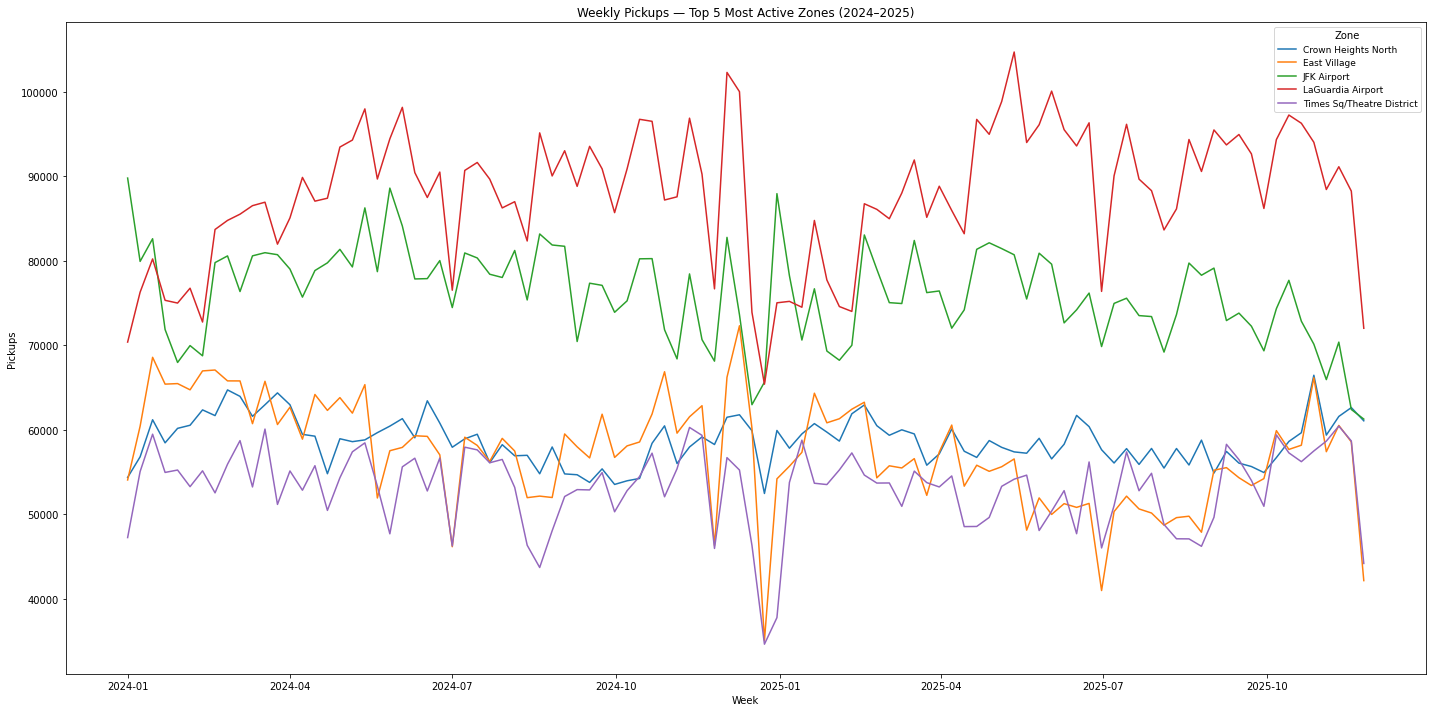

In [11]:
plt.figure(figsize=(20, 10))

for zone_name in pdf["Zone"].unique():
    sub = pdf[pdf["Zone"] == zone_name]
    plt.plot(sub["week"], sub["pickups"], label=zone_name)

plt.title("Weekly Pickups — Top 5 Most Active Zones (2024–2025)")
plt.xlabel("Week")
plt.ylabel("Pickups")
plt.legend(title="Zone", fontsize=9)
plt.tight_layout()
plt.show()

Now, ploting the 

In [12]:
#agg by zone
df_zone = (
    df.group_by("zone")
      .agg([
          pl.sum("pick_ups").alias("total_pickups"),
          pl.mean("avg_user_wait_time").alias("avg_wait_time")
      ])
      .filter(pl.col("total_pickups") > 0)
)

In [13]:
pdf_zone = df_zone.to_pandas()

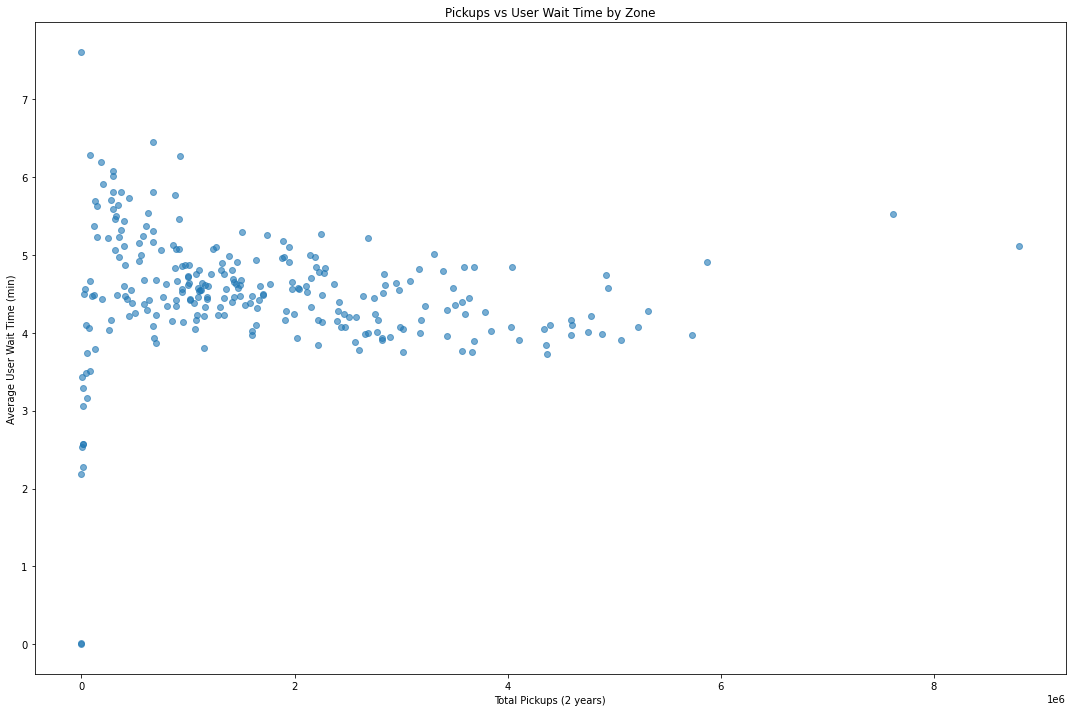

In [14]:
plt.figure(figsize=(15, 10))
plt.scatter(
    pdf_zone["total_pickups"],
    pdf_zone["avg_wait_time"],
    alpha=0.6
)

plt.xlabel("Total Pickups (2 years)")
plt.ylabel("Average User Wait Time (min)")
plt.title("Pickups vs User Wait Time by Zone")

plt.tight_layout()
plt.show()

Zones with both high pickup volume and elevated wait times represent structurally stressed areas where supply struggles to keep up with demand.

In [21]:
df_zone_agg = (
    df
    .group_by("zone")
    .agg([
        pl.mean("demand_ratio").alias("demand_ratio"),
        pl.mean("avg_user_wait_time").alias("avg_user_wait_time"),
        pl.sum("pick_ups").alias("total_pickups")
    ])
)

In [23]:
pdf_zone_agg = df_zone_agg.to_pandas()

In [24]:
pdf_zone_agg["demand_ratio_capped"] = pdf_zone_agg["demand_ratio"].replace(np.inf, np.nan)
pdf_zone_agg["demand_ratio_capped"] = pdf_zone_agg["demand_ratio_capped"].clip(upper=5)

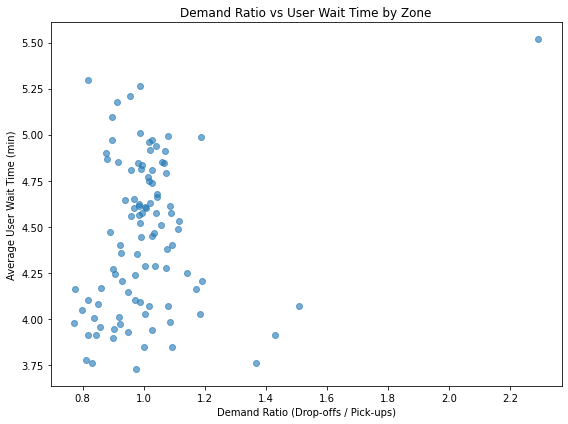

In [26]:
plt.figure(figsize=(8, 6))
plt.scatter(
    pdf_zone_agg["demand_ratio_capped"],
    pdf_zone_agg["avg_user_wait_time"],
    alpha=0.6
)

plt.xlabel("Demand Ratio (Drop-offs / Pick-ups)")
plt.ylabel("Average User Wait Time (min)")
plt.title("Demand Ratio vs User Wait Time by Zone")

plt.tight_layout()
plt.show()

There is not a linear relationship here, but zones with fewer drop-offs compared to pickups clearly suffer from higher and waiting times. This indicates local supply shortages. A re-distribution of drivers after drop off could help relief this shortages (stress)

In [27]:
df_zone_ratio = (
    df
    .group_by("zone")
    .agg(
        pl.mean("demand_ratio").alias("demand_ratio")
    )
)

In [28]:
pdf_zone_ratio = df_zone_ratio.to_pandas()

In [30]:
pdf_zone_ratio["demand_ratio_clean"] = (
    pdf_zone_ratio["demand_ratio"]
        .replace([np.inf, -np.inf], np.nan)
        .clip(upper=5)
)

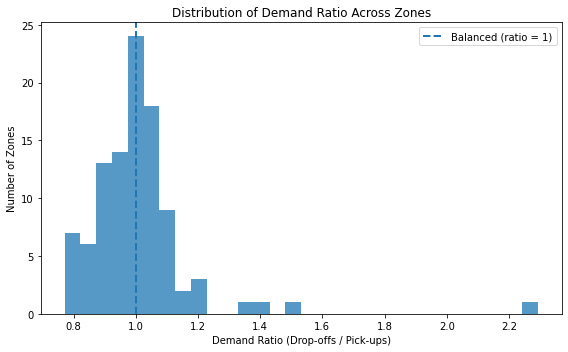

In [31]:
plt.figure(figsize=(8, 5))

plt.hist(
    pdf_zone_ratio["demand_ratio_clean"].dropna(),
    bins=30,
    alpha=0.75
)

plt.axvline(
    1.0,
    linestyle="--",
    linewidth=2,
    label="Balanced (ratio = 1)"
)

plt.xlabel("Demand Ratio (Drop-offs / Pick-ups)")
plt.ylabel("Number of Zones")
plt.title("Distribution of Demand Ratio Across Zones")
plt.legend()
plt.tight_layout()
plt.show()

Even if the system looks balanced on average, local imbalances are common. Some zones consistently have excess supply while others struggle with shortages, which makes driver redistribution both feasible and necessary.

Based on the exploratory analysis, passenger wait times are primarily driven by spatial supply–demand imbalance rather than demand alone. This motivates a forecasting approach focused on anticipating zone-level demand and proactively repositioning drivers before shortages occur.

## TimeSeries Forecasting
LightGBM is a good fit here because it trains fast, handles large tabular data well, and scales nicely when using a single model across many zones. Also good at non lineal relations

In [34]:
df

zone,time,drop_offs,pick_ups,avg_user_wait_time,demand_ratio
i32,datetime[μs],i64,i64,f64,f64
1,2024-01-01 00:00:00,4,0,0.0,inf
3,2024-01-01 00:00:00,26,24,7.006944,1.083333
4,2024-01-01 00:00:00,69,111,3.476877,0.621622
5,2024-01-01 00:00:00,6,10,9.493333,0.6
6,2024-01-01 00:00:00,16,15,5.848889,1.066667
…,…,…,…,…,…
260,2025-11-30 23:30:00,54,52,5.329487,1.038462
261,2025-11-30 23:30:00,16,19,5.17807,0.842105
262,2025-11-30 23:30:00,27,18,3.374074,1.5


In [44]:
df = df.with_columns([
    pl.col("zone").cast(pl.Int32),
    pl.col("time").cast(pl.Datetime),
    pl.col("pick_ups").cast(pl.Int64),
    pl.col("drop_offs").cast(pl.Int64),
    pl.col("avg_user_wait_time").cast(pl.Float64),

    # Clean avg_user_wait_time for modeling
    pl.col("avg_user_wait_time").fill_null(0.0).alias("avg_user_wait_time_model"),

    # Clean demand_ratio for modeling
    pl.when(pl.col("demand_ratio").is_infinite())
      .then(5.0)                     # cap extreme oversupply
      .otherwise(pl.col("demand_ratio"))
      .fill_null(0.0)
      .clip(None, 5.0)
      .alias("demand_ratio_model"),
])

In [45]:
zones = df.select("zone").unique().sort("zone")

In [46]:
# generating all time rows every 30 miuns, not missing any time where nothing happened
t_min = df.select(pl.col("time").min()).item()
t_max = df.select(pl.col("time").max()).item()

time_index = pl.DataFrame({
    "time": pl.datetime_range(
        start=t_min, end=t_max, interval=f"{time_window}m", eager=True
    )
})

In [47]:
grid = zones.join(time_index, how="cross")

In [48]:
df_full = (
    grid.join(df, on=["zone", "time"], how="left")
        .with_columns([
            pl.col("pick_ups").fill_null(0),
            pl.col("drop_offs").fill_null(0),
            pl.col("avg_user_wait_time_model").fill_null(0.0),
            pl.col("demand_ratio_model").fill_null(0.0),
        ])
        .sort(["zone", "time"])
)

In [49]:
ROLL_WIN = 6    # 6 * 30min = 3 hours
HORIZON = 1     # t+1 bucket (30 min ahead)

df_feat = df_full.with_columns([
    # Calendar features
    pl.col("time").dt.hour().alias("hour"),
    pl.col("time").dt.weekday().alias("dow"),         # 0=Mon
    pl.col("time").dt.month().alias("month"),
    pl.col("time").dt.ordinal_day().alias("day_of_year"),
    (pl.col("time").dt.weekday().is_in([5, 6])).cast(pl.Int8).alias("is_weekend"),

    # Lags (per zone)
    pl.col("pick_ups").shift(1).over("zone").fill_null(0).alias("lag_pu_1"),
    pl.col("pick_ups").shift(2).over("zone").fill_null(0).alias("lag_pu_2"),
    pl.col("pick_ups").shift(48).over("zone").fill_null(0).alias("lag_pu_48"),   # 1 day ago

    pl.col("drop_offs").shift(1).over("zone").fill_null(0).alias("lag_do_1"),
    pl.col("demand_ratio_model").shift(1).over("zone").fill_null(0).alias("lag_ratio_1"),
])

In [50]:
df_feat = df_feat.with_columns([
    # Rolling features (per zone)
    pl.col("pick_ups").rolling_mean(window_size=ROLL_WIN, min_periods=1).over("zone").alias(f"roll_pu_mean_{ROLL_WIN}"),
    pl.col("pick_ups").rolling_std(window_size=ROLL_WIN, min_periods=1).over("zone").fill_null(0).alias(f"roll_pu_std_{ROLL_WIN}"),
])

# Target: pickups at t+1 (per zone)
df_feat = df_feat.with_columns([
    pl.col("pick_ups").shift(-HORIZON).over("zone").alias("target_pickups_t_plus_1")
]).filter(pl.col("target_pickups_t_plus_1").is_not_null())


C:\Users\alana\AppData\Local\Temp\ipykernel_4672\2328286423.py:3: DeprecationWarning: the argument `min_periods` for `Expr.rolling_mean` is deprecated. It was renamed to `min_samples` in version 1.21.0.
  pl.col("pick_ups").rolling_mean(window_size=ROLL_WIN, min_periods=1).over("zone").alias(f"roll_pu_mean_{ROLL_WIN}"),
C:\Users\alana\AppData\Local\Temp\ipykernel_4672\2328286423.py:4: DeprecationWarning: the argument `min_periods` for `Expr.rolling_std` is deprecated. It was renamed to `min_samples` in version 1.21.0.
  pl.col("pick_ups").rolling_std(window_size=ROLL_WIN, min_periods=1).over("zone").fill_null(0).alias(f"roll_pu_std_{ROLL_WIN}"),


In [51]:
VALID_WEEKS = 8
t_cut = df_feat.select(pl.col("time").max()).item() - timedelta(weeks=VALID_WEEKS)

train_df = df_feat.filter(pl.col("time") < t_cut)
valid_df = df_feat.filter(pl.col("time") >= t_cut)

feature_cols = [
    "zone", "hour", "dow", "month", "day_of_year", "is_weekend",
    "lag_pu_1", "lag_pu_2", "lag_pu_48",
    "lag_do_1", "lag_ratio_1",
    f"roll_pu_mean_{ROLL_WIN}", f"roll_pu_std_{ROLL_WIN}",
]

In [52]:
train_pd = train_df.select(feature_cols + ["target_pickups_t_plus_1"]).to_pandas()
valid_pd = valid_df.select(feature_cols + ["target_pickups_t_plus_1"]).to_pandas()

In [53]:
X_train = train_pd[feature_cols]
y_train = train_pd["target_pickups_t_plus_1"].astype(float)

X_valid = valid_pd[feature_cols]
y_valid = valid_pd["target_pickups_t_plus_1"].astype(float)

# Treat zone as categorical
X_train["zone"] = X_train["zone"].astype("category")
X_valid["zone"] = X_valid["zone"].astype("category")

C:\Users\alana\AppData\Local\Temp\ipykernel_4672\3351306340.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["zone"] = X_train["zone"].astype("category")
C:\Users\alana\AppData\Local\Temp\ipykernel_4672\3351306340.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_valid["zone"] = X_valid["zone"].astype("category")


In [54]:
model = LGBMRegressor(
    objective="poisson",
    n_estimators=5000,
    learning_rate=0.03,
    num_leaves=64,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

In [55]:
model.fit(X_train, y_train,eval_set=[(X_valid, y_valid)], categorical_feature=["zone"], callbacks=[
        early_stopping(stopping_rounds=100),
        log_evaluation(period=100)
    ],
)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.432159 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2348
[LightGBM] [Info] Number of data points in the train set: 8160240, number of used features: 13
[LightGBM] [Info] Start training from score 3.923259
Training until validation scores don't improve for 100 rounds
[100]	valid_0's poisson: -181.503
[200]	valid_0's poisson: -183.542
[300]	valid_0's poisson: -183.871
[400]	valid_0's poisson: -183.959
[500]	valid_0's poisson: -183.998
[600]	valid_0's poisson: -184.022
[700]	valid_0's poisson: -184.04
[800]	valid_0's poisson: -184.055
[900]	valid_0's poisson: -184.067
[1000]	valid_0's poisson: -184.078
[1100]	valid_0's poisso

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, min_child_samples=50,
              n_estimators=5000, n_jobs=-1, num_leaves=64, objective='poisson',
              random_state=42, reg_lambda=1.0, subsample=0.8)

In [58]:
pred = model.predict(X_valid)

mae = mean_absolute_error(y_valid, pred)
rmse = root_mean_squared_error(y_valid, pred)

print(f"\nValidation MAE:  {mae:.3f}")
print(f"Validation RMSE: {rmse:.3f}")
print(f"Pred summary: min={pred.min():.3f}, median={np.median(pred):.3f}, max={pred.max():.3f}")


Validation MAE:  6.988
Validation RMSE: 12.585
Pred summary: min=0.000, median=35.020, max=763.375


Low error ~7 pickups by zone on avrg in 30 mins window, considering how different NYC zones are in size and demand, error is reasonable and useful for objective (re-distribuite drivers)

## Graph Construction

In [62]:
SHAPE_PATH = "taxi_zones/taxi_zones.shp"

In [63]:
gdf = gpd.read_file(SHAPE_PATH)

In [64]:
gdf

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."
...,...,...,...,...,...,...,...
258,259,0.126750,0.000395,Woodlawn/Wakefield,259,Bronx,"POLYGON ((1025414.782 270986.139, 1025138.624 ..."
259,260,0.133514,0.000422,Woodside,260,Queens,"POLYGON ((1011466.966 216463.005, 1011545.889 ..."
260,261,0.027120,0.000034,World Trade Center,261,Manhattan,"POLYGON ((980555.204 196138.486, 980570.792 19..."
261,262,0.049064,0.000122,Yorkville East,262,Manhattan,"MULTIPOLYGON (((999804.795 224498.527, 999824...."


In [67]:
if gdf.crs is None:
    gdf = gdf.set_crs(epsg=4326)

In [68]:
gdf.crs

<Projected CRS: EPSG:2263>
Name: NAD83 / New York Long Island (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - New York - counties of Bronx; Kings; Nassau; New York; Queens; Richmond; Suffolk.
- bounds: (-74.26, 40.47, -71.8, 41.3)
Coordinate Operation:
- name: SPCS83 New York Long Island zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [70]:
gdf_m = gdf.to_crs(epsg=3857)

In [71]:
gdf_m["centroid"] = gdf_m.geometry.centroid
gdf_m["cx"] = gdf_m["centroid"].x
gdf_m["cy"] = gdf_m["centroid"].y

In [72]:
gdf_nodes = gdf_m[["LocationID", "zone", "borough", "cx", "cy", "geometry"]].copy()
gdf_nodes.rename(columns={"zone": "ZoneName", "borough": "Borough"}, inplace=True)

gdf_nodes.head()

,LocationID,ZoneName,Borough,cx,cy,geometry
0,1,Newark Airport,EWR,-8.257012e+06,4.966993e+06,"POLYGON ((-8258175.533 4967457.203, -8258179.5..."
1,2,Jamaica Bay,Queens,-8.218862e+06,4.955975e+06,"MULTIPOLYGON (((-8217980.622 4959237.286, -821..."
2,3,Allerton/Pelham Gardens,Bronx,-8.220657e+06,4.992372e+06,"POLYGON ((-8220713.534 4993383.154, -8220638.4..."
3,4,Alphabet City,Manhattan,-8.235078e+06,4.971680e+06,"POLYGON ((-8234500.227 4971984.094, -8234502.1..."
4,5,Arden Heights,Staten Island,-8.258624e+06,4.946581e+06,"POLYGON ((-8257036.109 4948033.095, -8256954.5..."


In [74]:
K_NEIGHBORS = 6
G = build_knn_zone_graph(gdf_nodes, k=K_NEIGHBORS)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Is connected?", nx.is_connected(G))

Nodes: 260
Edges: 930
Is connected? True


In [79]:
show_neighbors(G, 132)

[(219, 3.314574263259304),
 (218, 3.978397620080792),
 (10, 4.7172998851591394),
 (203, 5.476325322797367),
 (216, 5.635193697723258),
 (139, 6.457519080280025),
 (2, 6.671161136030905),
 (86, 7.404993022440181),
 (30, 7.473448007395069),
 (117, 7.769908135340772)]

## Redistribution

In [94]:
wait_proxy = fit_wait_time_proxy(df_full, sample_n=500_000)

In [99]:
example_times = pick_top_demand_times(df_full, n=5)

examples = []
for i, t_bucket in enumerate(example_times, start=1):
    moves_df, final_df, kpis = run_snapshot(
        G=G,
        df_feat=df_feat,
        feature_cols=feature_cols,
        model=model,
        df_supply_source=df_full,   # o df_agg si no tienes df_full
        t_bucket=t_bucket,
        proxy_model=wait_proxy,
        max_distance_km=8.0
    )

    examples.append({
        "example_id": i,
        "time_bucket": t_bucket,
        "kpis": kpis,
        "moves_top10": moves_df.head(10) if not moves_df.empty else moves_df
    })

    print(f"\n=== Example {i} | t={t_bucket} ===")
    print("KPI:", kpis)
    display(examples[-1]["moves_top10"])


=== Example 1 | t=2025-11-02 01:00:00 ===
KPI: {'avg_wait_before_min': 4.812031318824075, 'avg_wait_after_min': 4.766910381920864, 'avg_wait_reduction_min': 0.04512093690321063, 'passenger_minutes_saved': 926.2609938126989, 'total_pred_pickups': 20528.407816522747}


,from_zone,to_zone,drivers_moved,distance_km
1,232,148,111.586972,1.072112
4,256,255,67.717414,1.196240
11,113,114,64.844728,0.710585
5,112,255,54.026141,1.800127
3,79,148,39.355779,1.389582
0,144,148,29.431033,0.729047
16,13,231,27.230334,1.241937
8,10,132,27.012479,4.717300
15,87,88,26.766349,0.675948
17,162,161,24.954622,0.626446



=== Example 2 | t=2025-11-02 01:30:00 ===
KPI: {'avg_wait_before_min': 4.884304223801339, 'avg_wait_after_min': 4.796231763399571, 'avg_wait_reduction_min': 0.0880724604017684, 'passenger_minutes_saved': 2026.9211831970897, 'total_pred_pickups': 23014.24501996076}


,from_zone,to_zone,drivers_moved,distance_km
1,79,148,107.057175,1.389582
17,170,164,85.454370,0.751848
9,137,234,83.554443,1.554430
20,162,230,75.627246,1.396044
21,87,144,71.496838,2.576329
11,112,255,68.757491,1.800127
22,68,246,67.074697,0.850085
14,13,231,62.400888,1.241937
0,232,148,56.915078,1.072112
8,186,234,55.043723,1.218996



=== Example 3 | t=2024-12-31 20:30:00 ===
KPI: {'avg_wait_before_min': 4.978008448526943, 'avg_wait_after_min': 4.8879491860236985, 'avg_wait_reduction_min': 0.0900592625032439, 'passenger_minutes_saved': 2922.1527902951348, 'total_pred_pickups': 32446.998887980895}


,from_zone,to_zone,drivers_moved,distance_km
18,158,249,69.156771,0.683408
43,237,75,47.019350,3.870120
16,88,13,43.303642,1.372265
62,234,90,40.973665,0.779165
60,145,262,39.889038,4.528395
71,255,260,38.178342,7.077630
32,161,170,37.979825,1.513560
63,48,140,36.164681,4.165057
73,211,261,33.726125,2.533720
78,234,137,32.433927,1.554430



=== Example 4 | t=2024-12-31 21:30:00 ===
KPI: {'avg_wait_before_min': 5.0023604413086415, 'avg_wait_after_min': 4.914134641946819, 'avg_wait_reduction_min': 0.08822579936182265, 'passenger_minutes_saved': 2896.611148878379, 'total_pred_pickups': 32831.79262563655}


,from_zone,to_zone,drivers_moved,distance_km
6,158,249,84.828143,0.683408
34,148,232,52.213520,1.072112
42,145,75,49.877124,6.599883
18,61,89,47.019617,5.982520
0,215,132,45.746525,6.988966
54,246,68,45.458469,0.850085
31,88,87,45.061991,0.675948
29,161,233,41.621937,1.440158
63,157,82,41.222302,3.614037
69,158,143,38.476858,6.914659



=== Example 5 | t=2024-12-31 22:00:00 ===
KPI: {'avg_wait_before_min': 4.9060947130665475, 'avg_wait_after_min': 4.843162624506281, 'avg_wait_reduction_min': 0.062932088560267, 'passenger_minutes_saved': 1851.399155647523, 'total_pred_pickups': 29419.000672042344}


,from_zone,to_zone,drivers_moved,distance_km
7,129,138,69.117415,2.825376
17,158,249,67.781224,0.683408
13,197,130,43.595190,4.358457
2,216,132,38.511840,5.635194
29,88,87,36.155836,0.675948
10,223,138,35.113910,5.333042
30,107,224,32.709298,1.108562
50,79,4,30.142466,1.148796
53,50,142,28.254289,1.864066
49,50,166,28.211113,7.394898


## Savings Estimations

In [100]:
def passenger_minutes_saved_from_kpis(kpis: dict) -> float:
    return (kpis["avg_wait_before_min"] - kpis["avg_wait_after_min"]) * kpis["total_pred_pickups"]

def run_many_windows_and_estimate(
    example_times, G, df_feat, feature_cols, model, df_supply_source, wait_proxy,
    max_distance_km=8.0
):
    rows = []
    for t_bucket in example_times:
        moves_df, final_df, kpis = run_snapshot(
            G=G,
            df_feat=df_feat,
            feature_cols=feature_cols,
            model=model,
            df_supply_source=df_supply_source,
            t_bucket=t_bucket,
            proxy_model=wait_proxy,
            max_distance_km=max_distance_km
        )
        pm_saved = passenger_minutes_saved_from_kpis(kpis)
        rows.append({
            "time": t_bucket,
            "avg_wait_before_min": kpis["avg_wait_before_min"],
            "avg_wait_after_min":  kpis["avg_wait_after_min"],
            "avg_wait_reduction_min": kpis["avg_wait_reduction_min"],
            "total_pred_pickups": kpis["total_pred_pickups"],
            "passenger_minutes_saved": pm_saved
        })
    return pd.DataFrame(rows)

In [101]:
all_times = df_feat.select("time").unique().to_series().to_list()

np.random.seed(42)
sample_times = list(np.random.choice(all_times, size=2000, replace=False))

df_impact = run_many_windows_and_estimate(
    sample_times, G, df_feat, feature_cols, model, df_full, wait_proxy, max_distance_km=8.0
)

avg_pm_saved_per_window = df_impact["passenger_minutes_saved"].mean()

# 30-min windows per day = 48
pm_saved_per_day = avg_pm_saved_per_window * 48
pm_saved_per_month = pm_saved_per_day * 30
pm_saved_per_year = pm_saved_per_day * 365

print("Avg passenger-minutes saved per 30-min window:", avg_pm_saved_per_window)
print("Estimated passenger-minutes saved per day:", pm_saved_per_day)
print("Estimated passenger-hours saved per day:", pm_saved_per_day/60)
print("Estimated passenger-hours saved per year:", pm_saved_per_year/60)

Avg passenger-minutes saved per 30-min window: 943.462857311744
Estimated passenger-minutes saved per day: 45286.21715096371
Estimated passenger-hours saved per day: 754.7702858493952
Estimated passenger-hours saved per year: 275491.15433502925
